# Oscillator Image Generation with Latent Strategy using FM and CNF

This notebook combines oscillator-based image generation with a learned latent strategy.

**Key Features:**
- **Latent Variable Decomposition**: Split image pixels into visible and latent components
- **Learned Latent Encoder**: Train an encoder to predict latent variables from visible pixels
- **OscFlow Physics**: Oscillator network dynamics for coupled visible+latent evolution
- **Flow Matching (FM)**: Regression-based training on straight-line interpolation paths
- **Continuous Normalizing Flow (CNF)**: Likelihood-based training with Jacobian trace estimation
- **Flexible Strategies**: Support both 'learned' encoder and 'random' latent sampling

## Part 1: Data Preparation and Setup
Load and prepare the sklearn digits dataset with periodic normalization

In [6]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import numpy as np
from jaxtyping import Array, Float, PRNGKeyArray
import matplotlib.pyplot as plt
from typing import Callable, Optional, Literal, Tuple, Any
import jax.random as jr
import diffrax
from sklearn import datasets

# Enable double precision
jax.config.update("jax_enable_x64", True)

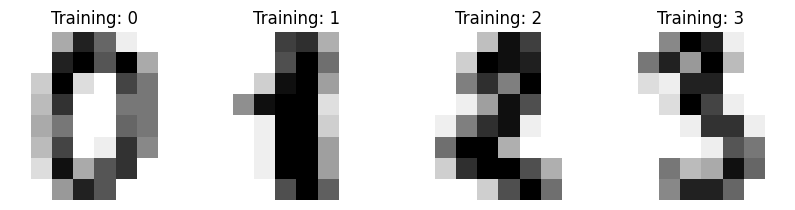

In [47]:
# Load and prepare dataset
digits = datasets.load_digits()

# Display a few sample images
_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, label in zip(axes, digits.images, digits.target):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title("Training: %i" % label)

# Normalize pixel intensities to [0, 1] then apply periodic transformation
images = digits.images / 16.0
flip = np.random.rand(*images.shape) > 0.5
images = np.where(flip, 2 - images, images)

image_h, image_w = images.shape[1:3]  # 8x8 images
n_pixels = image_h * image_w  # 64 pixels

## Part 2: Utility Functions

Helper functions for periodic wrapping and visualization

In [8]:
def wrap_to_one(x: Array) -> Array:
    """Wrap values to [-1, 1] for periodic image pixel representation."""
    return (x + 1) % 2.0 - 1.0


def plot_image(image):
    """Helper function to visualize a single image with periodic mapping."""
    image = np.where(image > 1, 2 - image, image)
    plt.imshow(image, cmap="gray_r")
    plt.axis("off")
    plt.show()

## Part 3: Latent Target Encoder

Define the encoder that maps visible pixels to latent variables

In [9]:
class LatentTargetEncoder(eqx.Module):
    """Maps visible pixels to learned latent variables."""

    net: Optional[eqx.nn.MLP]

    def __init__(self, vis_dim: int, lat_dim: int, key: PRNGKeyArray):
        if lat_dim > 0:
            self.net = eqx.nn.MLP(vis_dim, lat_dim, 64, 3, jax.nn.elu, key=key)
        else:
            self.net = None

    def __call__(self, x_vis: Array) -> Array:
        """Encode visible dimensions to latent space with periodic wrapping."""
        if self.net is None:
            return jnp.zeros((0,))
        return wrap_to_one(self.net(x_vis))

## Part 4: OscFlow Model with Joint Visible+Latent Dynamics

Define the OscFlow class extended with latent dimensions

In [21]:
class OscFlow(eqx.Module):
    """Oscillator-based flow model with time-varying coupling and locking."""

    coupling_matrix: Array
    locking_weight: Array
    use_time_weights: bool
    n_phase_ref: int
    use_const_bias: bool
    dim: int
    net: eqx.nn.MLP

    def __init__(
        self,
        dim: int,
        h: int = 64,
        n_phase_ref: int = 2,
        key: PRNGKeyArray = jax.random.PRNGKey(0),
        use_time_weights: bool = True,
        use_const_bias: bool = False,
        coupling_matrix: Optional[Array] = None,
        locking_weight: Optional[Array] = None,
    ):
        cpl_key, lock_key, net_key = jax.random.split(key, num=3)

        # Static coupling coefficients between oscillators and reference phases
        self.coupling_matrix = (
            jax.random.normal(cpl_key, (dim, dim + n_phase_ref)) * 0.01
            if coupling_matrix is None
            else coupling_matrix
        )

        # Static locking coefficients
        self.locking_weight = (
            jax.random.normal(lock_key, (dim,)) * 0.01
            if locking_weight is None
            else locking_weight
        )

        # Neural network for time-dependent weight modulation
        self.net = eqx.nn.MLP(
            in_size=1,
            out_size=dim * (dim + n_phase_ref + 1) + (dim if use_const_bias else 0),
            width_size=h,
            depth=2,
            activation=jax.nn.elu,
            key=net_key,
        )
        self.use_time_weights = use_time_weights
        self.use_const_bias = use_const_bias
        self.n_phase_ref = n_phase_ref
        self.dim = dim

    def __call__(self, t: Float, x_t: Array) -> Array:
        """Compute oscillator dynamics including coupling, locking, and time-varying modulation."""
        dim = x_t.shape[-1]

        # Create reference phases
        ref_phase = jnp.linspace(0, 1, self.n_phase_ref, endpoint=True)
        phase = jnp.concatenate([x_t, ref_phase], axis=-1)

        # Compute pairwise phase differences
        phase_diff = (phase[:, None] - phase[None, :])[: -self.n_phase_ref, :]

        # Sinusoidal coupling
        coupling = jnp.sin(jnp.pi * phase_diff) * self.coupling_matrix

        # Locking term
        locking = self.locking_weight * jnp.sin(2 * jnp.pi * x_t)

        bias = 0.0

        # Time-dependent weight modulation
        if self.use_time_weights:
            time_weight = self.net(t)
            n_coupling_weights = dim * (dim + self.n_phase_ref)

            coupling_time_weight = time_weight[:n_coupling_weights].reshape(
                dim, dim + self.n_phase_ref
            )
            locking_time_weight = time_weight[
                n_coupling_weights : n_coupling_weights + dim
            ]

            coupling = coupling * coupling_time_weight
            locking = locking * locking_time_weight

            if self.use_const_bias:
                bias = time_weight[n_coupling_weights + dim :]

        return coupling.sum(axis=1) - locking + bias

    def get_time_weights(self, t: Float):
        """Extract time-varying weights for visualization."""
        if self.use_time_weights:
            time_weight = self.net(jnp.array([t]))
            n_coupling_weights = self.dim * (self.dim + self.n_phase_ref)
            coupling_time_weight = time_weight[:n_coupling_weights].reshape(
                self.dim, self.dim + self.n_phase_ref
            )
            locking_time_weight = time_weight[
                n_coupling_weights : n_coupling_weights + self.dim
            ]
            bias = 0.0
            if self.use_const_bias:
                bias = time_weight[n_coupling_weights + self.dim :]
            return coupling_time_weight, locking_time_weight, bias
        else:
            return None

## Part 5: Joint Model with Latent Strategy

Define the joint model that combines OscFlow with latent encoder

In [87]:
class JointImageModel(eqx.Module):
    """Joint model combining OscFlow with latent encoder for image generation."""

    flow: OscFlow
    encoder: LatentTargetEncoder
    vis_dim: int
    lat_dim: int
    latent_strategy: Literal["learned", "random"]

    def __init__(
        self,
        vis_dim: int,
        lat_dim: int,
        key: PRNGKeyArray,
        latent_strategy: Literal["learned", "random"] = "learned",
    ):
        k_flow, k_enc = jax.random.split(key)
        self.vis_dim = vis_dim
        self.lat_dim = lat_dim
        self.latent_strategy = latent_strategy

        self.flow = OscFlow(vis_dim + lat_dim, key=k_flow)
        self.encoder = LatentTargetEncoder(vis_dim, lat_dim, k_enc)


def get_target_latents(
    model: JointImageModel, x_vis_1: Array, key: PRNGKeyArray
) -> Array:
    """Generate target latent variables using either learned encoder or random sampling."""
    if model.lat_dim == 0:
        if len(x_vis_1.shape) == 1:
            return jnp.zeros((1,))
        return jnp.zeros((x_vis_1.shape[0], 0))

    if model.latent_strategy == "learned":
        if len(x_vis_1.shape) == 1:
            return model.encoder(x_vis_1)
        return jax.vmap(model.encoder)(x_vis_1)
    else:
        # Random Strategy: sample noise from standard distribution
        if len(x_vis_1.shape) == 1:
            raw_noise = jax.random.normal(key, (model.lat_dim))
            return wrap_to_one(raw_noise)
        raw_noise = jax.random.normal(key, (x_vis_1.shape[0], model.lat_dim))
        return wrap_to_one(raw_noise)

## Part 6: CNF Model Definition

Define the Continuous Normalizing Flow with trace estimators

In [85]:
def approx_logp_wrapper(t, y, args):
    """Hutchinson trace estimator for log-probability gradient."""
    y, _ = y
    *args, eps, func = args
    fn = lambda y: func(t, y)
    f, vjp_fn = jax.vjp(fn, y)
    (eps_dfdy,) = vjp_fn(eps)
    logp = jnp.sum(eps_dfdy * eps)
    return f, logp


def exact_logp_wrapper(t, y, args):
    """Exact Jacobian trace computation."""
    y, _ = y
    *args, _, func = args
    fn = lambda y: func(t, y)
    f, vjp_fn = jax.vjp(fn, y)
    (size,) = y.shape
    eye = jnp.eye(size)
    (dfdy,) = jax.vmap(vjp_fn)(eye)
    logp = jnp.trace(dfdy)
    return f, logp


class CNF(eqx.Module):
    """Continuous Normalizing Flow for likelihood-based training with joint visible+latent model."""

    model: JointImageModel
    exact_logp: bool
    t0: float
    t1: float
    dt0: float

    def __init__(
        self,
        model: JointImageModel,
        exact_logp: bool,
        t0: float = 0.0,
        t1: float = 1.0,
        dt0: float = 0.05,
    ):
        self.model = model
        self.exact_logp = exact_logp
        self.t0 = t0
        self.t1 = t1
        self.dt0 = dt0

    def train(self, x_vis_1: Array, *, key: PRNGKeyArray) -> Array:
        """Compute log-likelihood by integrating backward through time.

        Handles latent variable generation and backward ODE integration.
        """
        # Get target latent variables
        lat_1 = get_target_latents(self.model, x_vis_1, key)
        print(lat_1.shape, x_vis_1.shape)

        x_1 = jnp.concatenate([x_vis_1, lat_1])

        if self.exact_logp:
            term = diffrax.ODETerm(exact_logp_wrapper)
        else:
            term = diffrax.ODETerm(approx_logp_wrapper)

        solver = diffrax.Tsit5()
        eps = jr.normal(key, x_1.shape)
        delta_log_likelihood = 0.0
        y = (x_1, delta_log_likelihood)

        sol = diffrax.diffeqsolve(
            term,
            solver,
            self.t1,
            self.t0,
            -self.dt0,
            y,
            (eps, self.model.flow),
        )
        (x,), (delta_log_likelihood,) = sol.ys
        return delta_log_likelihood

    def sample(self, *, key: PRNGKeyArray) -> Array:
        """Generate a sample by integrating forward from noise."""
        total_dim = self.model.vis_dim + self.model.lat_dim
        y = jr.uniform(key, (total_dim,), minval=-1, maxval=1)
        term = diffrax.ODETerm(self.model.flow)
        solver = diffrax.Tsit5()

        sol = diffrax.diffeqsolve(term, solver, self.t0, self.t1, self.dt0, y)
        (y,) = sol.ys
        return y[: self.model.vis_dim]  # Return only visible dimensions

## Part 7: Loss Functions for FM and CNF Training

Define loss functions with separate visible and latent components

In [73]:
def loss_fm(
    model: JointImageModel,
    x_vis_1: Array,
    x_0_full: Array,
    t: Array,
    key: PRNGKeyArray,
) -> Tuple[Array, Tuple[Array, Array]]:
    """Flow matching loss with separate visible and latent components."""
    # Get target latents
    target_latents = get_target_latents(model, x_vis_1, key)
    x_1_full = jnp.concatenate([x_vis_1, target_latents], axis=1)

    # Target velocity
    u_t = wrap_to_one(x_1_full - x_0_full)
    x_t = wrap_to_one(x_0_full + t * u_t)

    # Predict velocity
    v_pred = jax.vmap(model.flow)(t, x_t)
    tot_loss = optax.l2_loss(v_pred, u_t)

    # Separate losses for visible and latent dimensions
    vis_loss = jnp.mean(tot_loss[:, : model.vis_dim])
    lat_loss = jnp.mean(tot_loss[:, model.vis_dim :]) if model.lat_dim > 0 else 0.0

    return tot_loss.mean(), (vis_loss, lat_loss)


def loss_cnf(
    cnf: CNF,
    x_vis_batch: Array,
    train_key: PRNGKeyArray,
) -> Tuple[Array, Tuple[Array, Array]]:
    """Compute negative log-likelihood for CNF training.

    We minimize -sum(log p(x_i)), which means maximizing log-likelihood.
    """
    log_likelihood = jax.vmap(cnf.train)(x_vis_batch, key=train_key)
    return (
        -jnp.mean(log_likelihood),
        (-log_likelihood, jnp.zeros_like(log_likelihood)),
    )  # Return negative log-likelihood with dummy second component

## Part 8: Training Loop Implementation

Implement training functions for FM and CNF

In [61]:
@eqx.filter_jit
def train_step_fm(
    model: JointImageModel,
    optim: optax.GradientTransformation,
    opt_state: optax.OptState,
    x_vis_batch: Array,
    key: PRNGKeyArray,
) -> Tuple[Array, Tuple[Array, Array], JointImageModel, optax.OptState]:
    """Single FM training step."""
    k1, k2, k3 = jax.random.split(key, 3)

    total_dim = model.vis_dim + model.lat_dim
    x_0 = jax.random.uniform(k1, (len(x_vis_batch), total_dim), minval=-1, maxval=1)
    t = jax.random.uniform(k2, (len(x_vis_batch), 1))

    def loss_wrapper(m: JointImageModel) -> Tuple[Array, Tuple[Array, Array]]:
        return loss_fm(m, x_vis_batch, x_0, t, k3)

    (loss, aux), grads = eqx.filter_value_and_grad(loss_wrapper, has_aux=True)(model)
    updates, opt_state = optim.update(grads, opt_state, eqx.filter(model, eqx.is_array))
    model = eqx.apply_updates(model, updates)

    return loss, aux, model, opt_state


@eqx.filter_jit
def train_step_cnf(
    cnf: CNF,
    optim: optax.GradientTransformation,
    opt_state: optax.OptState,
    x_vis_batch: Array,
    keys: Array,
) -> Tuple[Array, Tuple[Array, Array], CNF, optax.OptState]:
    """Single CNF training step."""

    def loss_wrapper(c: CNF) -> Tuple[Array, Tuple[Array, Array]]:
        return loss_cnf(c, x_vis_batch, keys)

    (loss, aux), grads = eqx.filter_value_and_grad(loss_wrapper, has_aux=True)(cnf)
    updates, opt_state = optim.update(grads, opt_state, eqx.filter(cnf, eqx.is_array))
    cnf = eqx.apply_updates(cnf, updates)

    return loss, aux, cnf, opt_state


def train_fm(
    model: JointImageModel,
    dataset_fn: Callable,
    batch_size: int = 256,
    lr: float = 1e-3,
    n_iters: int = 100,
    print_every: int = 10,
    key: PRNGKeyArray = jr.PRNGKey(0),
) -> JointImageModel:
    """Train model using flow matching."""
    optim = optax.adam(lr)
    opt_state = optim.init(eqx.filter(model, eqx.is_array))
    dataloader = dataset_fn(batch_size)

    for iter, x_batch in zip(range(n_iters), dataloader):
        key, k_step = jax.random.split(key)
        loss, (vis_loss, lat_loss), model, opt_state = train_step_fm(
            model, optim, opt_state, x_batch, k_step
        )

        if iter % print_every == 0:
            print(
                f"Iter {iter}, Loss: {loss:.4f}, Vis: {vis_loss:.4f}, Lat: {lat_loss:.4f}"
            )

    return model


def train_cnf(
    cnf: CNF,
    dataset_fn: Callable,
    batch_size: int = 256,
    lr: float = 1e-3,
    n_iters: int = 100,
    print_every: int = 10,
    loss_key: PRNGKeyArray = jr.PRNGKey(0),
) -> CNF:
    """Train CNF model by maximizing data log-likelihood."""
    optim = optax.adam(lr)
    opt_state = optim.init(eqx.filter(cnf, eqx.is_array))
    dataloader = dataset_fn(batch_size)

    loss_keys = jr.split(loss_key, n_iters)

    for iter, x_batch in zip(range(n_iters), dataloader):
        # Generate unique random keys for Hutchinson estimator in this batch
        key = loss_keys[iter]
        keys = jr.split(key, batch_size)

        loss, (loss_val, _), cnf, opt_state = train_step_cnf(
            cnf, optim, opt_state, x_batch, keys
        )

        if iter % print_every == 0:
            print(f"Iter {iter}, Loss: {loss:.4f}")

    return cnf

## Part 9: Visualization and Sampling Functions

Utilities for sampling and analyzing learned models

In [62]:
def visualize_sample_fm(
    model: JointImageModel,
    key=jr.PRNGKey(0),
    n_samples: int = 1,
    t0: float = 0.0,
    t1: float = 1.0,
    dt0: float = 0.05,
):
    """Visualize generated samples from FM-trained model."""
    fig, ax = plt.subplots(2, n_samples, figsize=(n_samples * 2, 4))

    # Sample initial conditions
    total_dim = model.vis_dim + model.lat_dim
    ys = jax.random.uniform(key, (n_samples, total_dim), minval=-1, maxval=1)
    orig_images = jnp.where(images > 1, 2 - images, images)

    for i, y in enumerate(ys):
        # Plot initial state
        ax[0, i].imshow(y[: model.vis_dim].reshape(image_h, image_w), cmap="gray_r")
        ax[0, i].axis("off")

        # Integrate forward
        term = diffrax.ODETerm(lambda t, x, args: model.flow(jnp.array([t]), x))
        solver = diffrax.Tsit5()
        sol = diffrax.diffeqsolve(term, solver, t0, t1, dt0, y)
        (y,) = sol.ys

        # Visualize final state
        vis_dims = y[: model.vis_dim]
        sample_image = vis_dims.reshape(image_h, image_w)
        sample_image = sample_image % 2.0
        sample_image = jnp.where(sample_image > 1, 2 - sample_image, sample_image)

        ax[1, i].imshow(sample_image, cmap="gray_r")
        ax[1, i].axis("off")

    ax[0, 0].set_title("Initial State", fontsize=12)
    ax[1, 0].set_title("Generated Image", fontsize=12)
    plt.tight_layout()
    plt.show()


def plot_net_output(model: JointImageModel, n_steps: int = 20):
    """Visualize time-varying weights in OscFlow."""
    time_points = jnp.linspace(0, 1.0, n_steps)
    cpl_w, lock_w = [], []

    for t in time_points:
        weights = model.flow.get_time_weights(t)
        if weights is not None:
            cpl, lock, bias = weights
            cpl_w.append(cpl.flatten())
            lock_w.append(lock.flatten())

    cpl_w = jnp.stack(cpl_w, axis=0)
    lock_w = jnp.stack(lock_w, axis=0)

    fig, axes = plt.subplots(2, 1, figsize=(8, 6))
    axes[0].plot(time_points, cpl_w, alpha=0.6)
    axes[0].set_title("Coupling Weights over Time")
    axes[0].set_ylabel("Weight magnitude")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(time_points, lock_w, alpha=0.6)
    axes[1].set_title("Locking Weights over Time")
    axes[1].set_ylabel("Weight magnitude")
    axes[1].set_xlabel("Time (t)")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_latent_states(model: JointImageModel, x_vis: Array):
    """Visualize latent variable encodings for given visible inputs."""
    if model.lat_dim == 0:
        print("No latent dimensions to visualize.")
        return

    latents = jax.vmap(model.encoder)(x_vis)
    latents = np.array(latents)

    fig, axes = plt.subplots(1, model.lat_dim, figsize=(4 * model.lat_dim, 4))

    for i in range(model.lat_dim):
        axes[i].hist(latents[:, i], bins=20, color="skyblue", edgecolor="black")
        axes[i].set_title(f"Latent Dimension {i+1}")
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()


def image_dataset(batch_size: int):
    """Create infinite dataloader for image dataset."""

    def dataloader():
        num_samples = images.shape[0]
        indices = np.arange(num_samples)
        print(num_samples)

        while True:
            np.random.shuffle(indices)
            for start_idx in range(0, num_samples, batch_size):
                if start_idx + batch_size > num_samples:
                    break
                excerpt = indices[start_idx : start_idx + batch_size]
                yield jnp.array(images[excerpt].reshape(-1, n_pixels))

    return dataloader()

## Part 10: Experiment 1 - OscFlow-FM with Latent Strategy

Train OscFlow using flow matching with different latent configurations

Experiment 1: OscFlow with Flow Matching (FM)

Training: lat_dim=0, strategy=learned
1797
Iter 0, Loss: 0.1657, Vis: 0.1657, Lat: 0.0000
Iter 200, Loss: 0.1045, Vis: 0.1045, Lat: 0.0000
Iter 400, Loss: 0.0905, Vis: 0.0905, Lat: 0.0000
Iter 600, Loss: 0.0941, Vis: 0.0941, Lat: 0.0000
Iter 800, Loss: 0.0897, Vis: 0.0897, Lat: 0.0000
Visualizing samples...


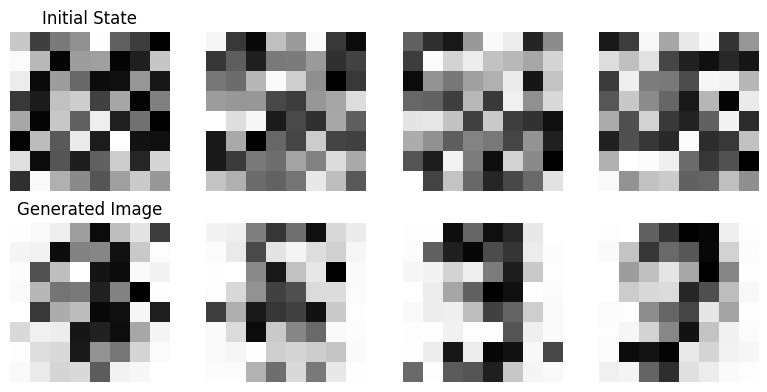

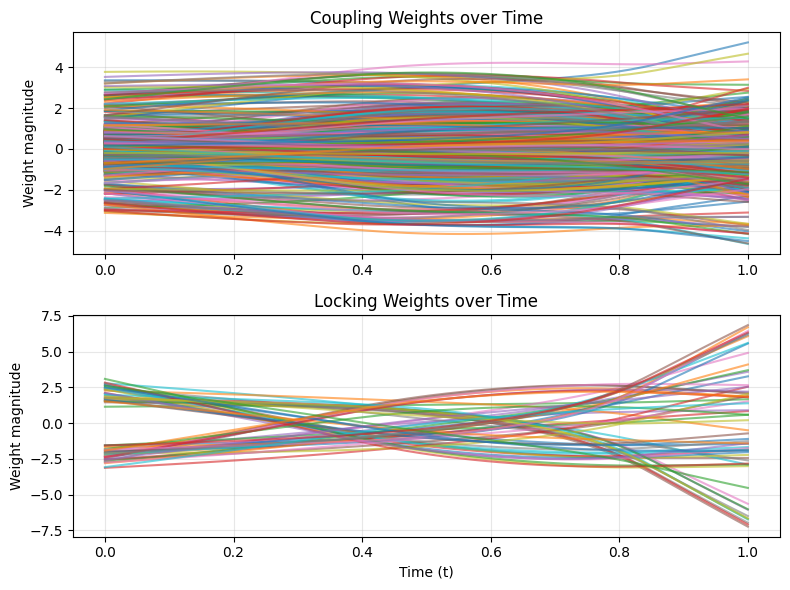


Training: lat_dim=4, strategy=learned
1797
Iter 0, Loss: 0.1685, Vis: 0.1689, Lat: 0.1616
Iter 200, Loss: 0.1005, Vis: 0.1052, Lat: 0.0260
Iter 400, Loss: 0.0877, Vis: 0.0924, Lat: 0.0125
Iter 600, Loss: 0.0869, Vis: 0.0914, Lat: 0.0141
Iter 800, Loss: 0.0879, Vis: 0.0928, Lat: 0.0094
Visualizing samples...


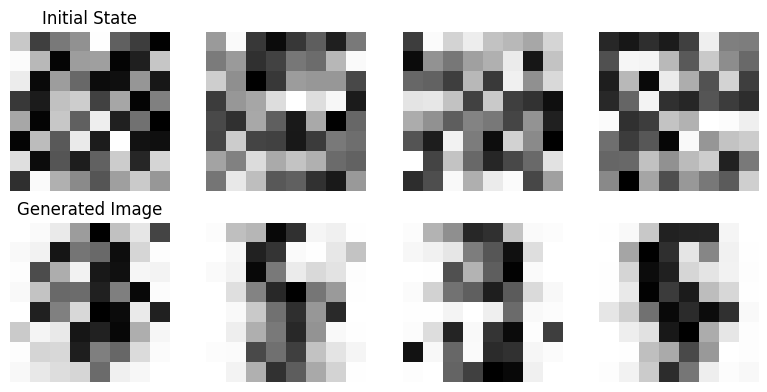

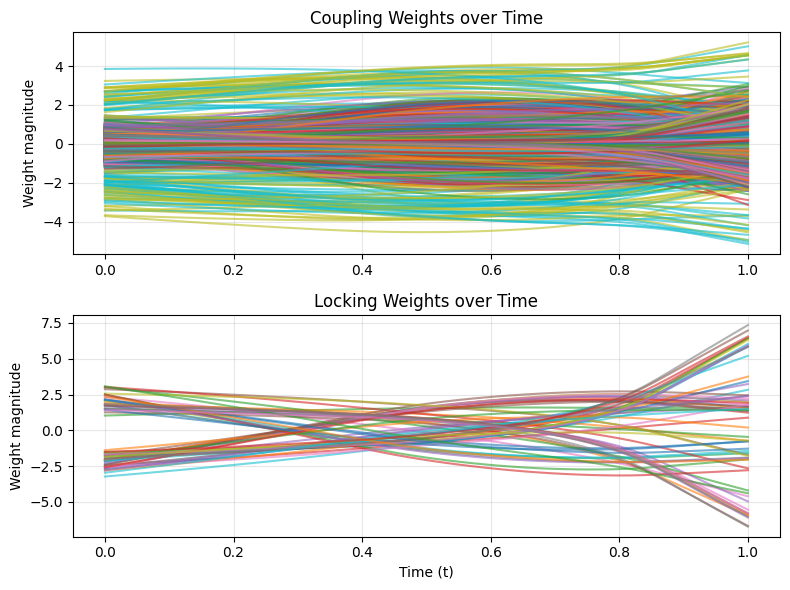

1797


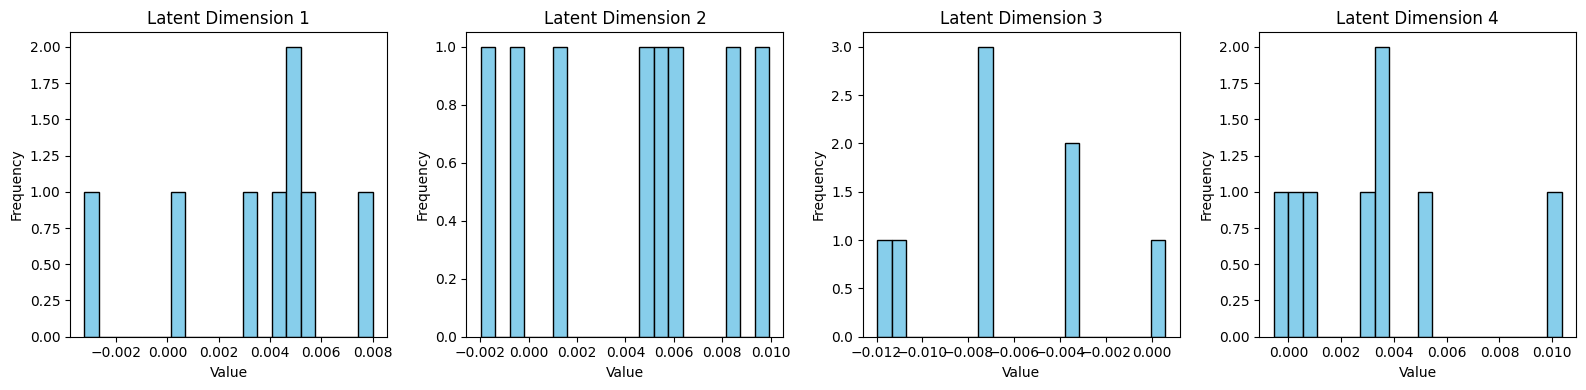

In [70]:
# Test FM with different latent dimensions and strategies
print("=" * 60)
print("Experiment 1: OscFlow with Flow Matching (FM)")
print("=" * 60)

latent_dims = [0, 4]
strategies = ["learned"]

for lat_dim in latent_dims:
    for strategy in strategies:
        if lat_dim == 0 and strategy == "random":
            continue  # Skip irrelevant combination

        print(f"\nTraining: lat_dim={lat_dim}, strategy={strategy}")

        # Initialize model
        key = jax.random.PRNGKey(428)
        model_key, train_key, viz_key = jax.random.split(key, 3)
        model = JointImageModel(n_pixels, lat_dim, model_key, latent_strategy=strategy)

        # Train
        model = train_fm(
            model,
            image_dataset,
            batch_size=128,
            lr=1e-3,
            n_iters=1000,
            print_every=200,
            key=train_key,
        )

        # Visualize results
        print("Visualizing samples...")
        visualize_sample_fm(model, key=viz_key, n_samples=4)
        plot_net_output(model, n_steps=50)
        if lat_dim > 0:
            # Pick a few images to visualize latent states
            sample_x_vis = image_dataset(batch_size=8).__next__()
            plot_latent_states(model, sample_x_vis)

## Part 11: Experiment 2 - OscFlow-CNF with Latent Strategy

Train OscFlow using continuous normalizing flow with different trace estimators

In [88]:
# Test CNF with different latent dimensions and trace methods
print("\n" + "=" * 60)
print("Experiment 2: OscFlow with Continuous Normalizing Flow (CNF)")
print("=" * 60)

latent_dims = [0, 2]  # Reduced for faster demo
exact_logp_options = [False]  # Hutchinson (False) is faster than exact (True)

for lat_dim in latent_dims:
    for exact_logp in exact_logp_options:
        trace_method = "exact" if exact_logp else "hutchinson"
        print(f"\nTraining: lat_dim={lat_dim}, trace_method={trace_method}")

        # Initialize model
        key = jax.random.PRNGKey(42)
        model_key, train_key, viz_key = jax.random.split(key, 3)
        model = JointImageModel(n_pixels, lat_dim, model_key, latent_strategy="learned")

        # Wrap in CNF for likelihood-based training
        cnf = CNF(model, exact_logp=exact_logp)

        # Train CNF on image dataset
        cnf = train_cnf(
            cnf,
            image_dataset,
            batch_size=128,
            lr=1e-3,
            n_iters=30,
            print_every=10,
            loss_key=train_key,
        )

        print(f"Training complete for lat_dim={lat_dim}, trace_method={trace_method}")
        # Visualize results
        print("Visualizing samples...")
        visualize_sample_fm(cnf.model, key=viz_key, n_samples=4)
        plot_net_output(cnf.model, n_steps=50)

        if lat_dim > 0:
            # Pick a few images to visualize latent states
            sample_x_vis = image_dataset(batch_size=8).__next__()
            plot_latent_states(cnf.model, sample_x_vis)


Experiment 2: OscFlow with Continuous Normalizing Flow (CNF)

Training: lat_dim=0, trace_method=hutchinson
1797
(1,) (64,)


ValueError: Terms are not compatible with solver! Got:
ODETerm(vector_field=<function approx_logp_wrapper>)
but expected:
diffrax.AbstractTerm
Note that terms are checked recursively: if you scroll up you may find a root-cause error that is more specific.